In [1]:
import pandas as pd
from IPython.display import Image, display
import random
import torch

from preprocessor import Preprocessor
from visualizer import Visualizer
from semantic import SemanticAnalyser
from agent import Agent, PRICE_MAPPER
from config_local import config

# Project description

We study how large language models (LLMs) navigate Wikipedia in the Wikispeedia game, where a human player is given a start and a destination page, and their goal is to navigate from the start to the end in as few steps as possible. At each step, only outgoing links from the current page are available. We replicate this setup with LLMs and analyze how their reasoning compares to human navigation. Our analyses range from success metrics to semantic analysis of the navigation, as well as category shift patterns, so that differences between human and LLM navigation can be observed. 

With this project, we aim to answer the following question: **Do LLMs show similar semantic navigation patterns to those of human players in Wikispeedia, and how do these patterns vary across prompting strategies and model sizes?**

Previous research has identified a 'zooming out' phase early in navigation followed by a 'zooming in' process for human players, which we would like to investigate whether LLMs act similarly as humans or not [1].

# Explanatory analysis

At first, let's get started by exploring the Wikispeedia dataset. The dataset is composed of six files:

- *articles.tsv*: contains the list of wikipedia articles


- *categories.tsv*: contains the list of wikipedia categories


- *links.tsv*: contains the list of links between articles


- *paths_finished.tsv*: contains the list of human paths finished by the users


- *paths_unfinished.tsv*: contains the list of human paths unfinished by the users


- *shortest-path-distance-matrix.txt*: contains the shortest path distance between each pair of articles

In our project we use the following files: *categories.tsv*, *links.tsv*, *paths_finished.tsv* and *paths_unfinished.tsv*.

### High-level overview of the most common finished and unfinished paths

Here we show the five most common finished and unfinished paths based on the start page in the Wikispeedia dataset, you can see below that *Brain -> Telephone* navigation occurs over 1000 times in both the finished and unfinished files. The next navigation starting with *Brain* is only represented in 11 games, namely the *Brain -> DVD*, that is followed by *Brain -> Chestnut* with a total of 9 cases. In general, the trend in the dataset is that there tends to be one highly represented start–destination pair, while the next pairs with the same start are, in general, represented significantly less.

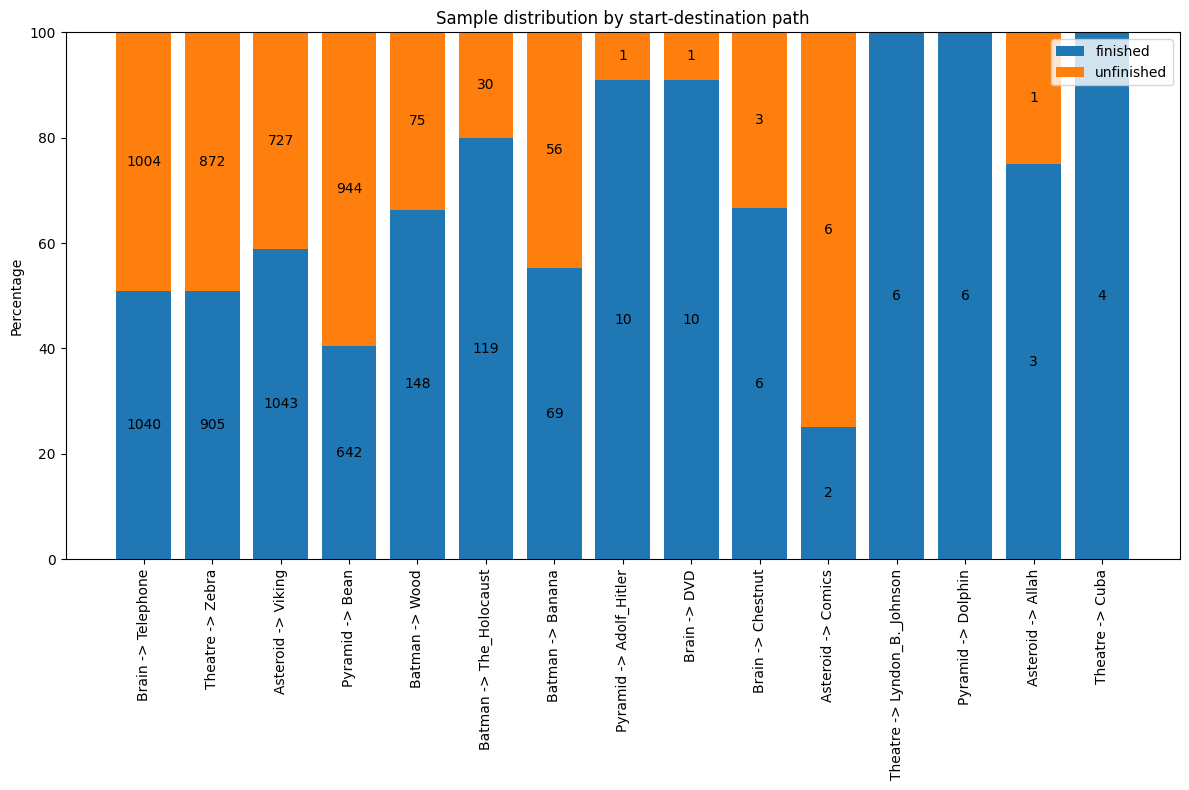

In [2]:
# initializing high level instances, with config
preprocessor = Preprocessor(config=config)
visualizer = Visualizer(config=config)
semantic_analyser = SemanticAnalyser(config=config)

# parse input files into a merged df
df = preprocessor.get_merged_input_files()

# top k start paths with top 3 destination plotted regarding finished/unfinished source
top_k_df = preprocessor.get_top_paths_for_starts(df, 5)
visualizer.visualize_top_k(top_k_df, 'top_k_analysis.png')

### Articles, links, categories overview

At first we parse the three files via the *Preprocessor.parse_input_file* method, which dynamically reads the column names from the comment lines.

In [3]:
# parsing auxiliary files into pd.DataFrame
articles = preprocessor.parse_input_file(config.input_file_articles)
categories = preprocessor.parse_input_file(config.input_file_categories)
links = preprocessor.parse_input_file(config.input_file_links)

In [4]:
# number of articles
print(f'Total number of articles: {len(articles)}')

Total number of articles: 4604


All of the **articles** have at least one outgoing or target **link**, thus we don't have any links which are unreachable. On average, each article appears ~26 times as source and ~29 as target.

*Source links' statistics*:

In [5]:
print(links['linkSource'].value_counts().describe())

count    4587.000000
mean       26.135165
std        24.194229
min         1.000000
25%        11.000000
50%        19.000000
75%        33.000000
max       294.000000
Name: count, dtype: float64


*Target links' statistics*:

In [6]:
print(links['linkTarget'].value_counts().describe())

count    4135.000000
mean       28.992019
std        65.560574
min         1.000000
25%         4.000000
50%        10.000000
75%        29.000000
max      1551.000000
Name: count, dtype: float64


Regarding the **categories**, we have 129 unique categories. Each article can belong to multiple categories, with a maximum of three categories per article.

*Categories statistics*:

In [7]:
categories.describe()

,article,category
count,5204,5204
unique,4598,129
top,United_Kingdom,subject.Countries
freq,3,229


The distribution is uneven: a few categories account for a large share of assignments (e.g.: *subject.Countries* is the most frequent with 229 occurences), while many categories are relatively sparse as the different percentiles show.

In [8]:
categories['category'].value_counts().describe()

count    129.000000
mean      40.341085
std       34.678095
min        2.000000
25%       18.000000
50%       27.000000
75%       51.000000
max      229.000000
Name: count, dtype: float64

For both the finished and unfinished paths we resolve the articles to their first category (e.g.: *subject.People.Historical_figures* becomes *Historical_figures*), if it is missing, then we assign 'Unknown'. *cat_df* contains aggregated counts per category, while *cat_df_clean* is the same table with 'Unknown' filtered out. *article_cats_finished* represents finished paths expressed as categories instead of articles, and *article_cats* includes these sequences for both finished and unfinished paths.

In [9]:
cat_df_clean, cat_df, article_cats_finished, article_cats = preprocessor.get_clean_categories_df(df, categories)

In [10]:
# Count missing categories
mis_count = cat_df.loc[cat_df["category"] == "Unknown", "count"].sum()
mis_perc = mis_count / len(article_cats) 

# Prints
print(f"'No. of unknown categories: {mis_count}")
print(f"'Unknown' categories account for approximately {mis_perc:.2%} of all entries.")

'No. of unknown categories: 33559
'Unknown' categories account for approximately 7.05% of all entries.


Visualizing the top 15 category distributions across navigation (finished + unfinished). As the plot shows, Countries are the most common category (over 40,000 occurrences), followed by General_Biology and Food_and_agriculture. Note that high-frequency categories can dominate both distributions and shift counts; pairwise analyses mitigate this by focusing on cross-category transitions.

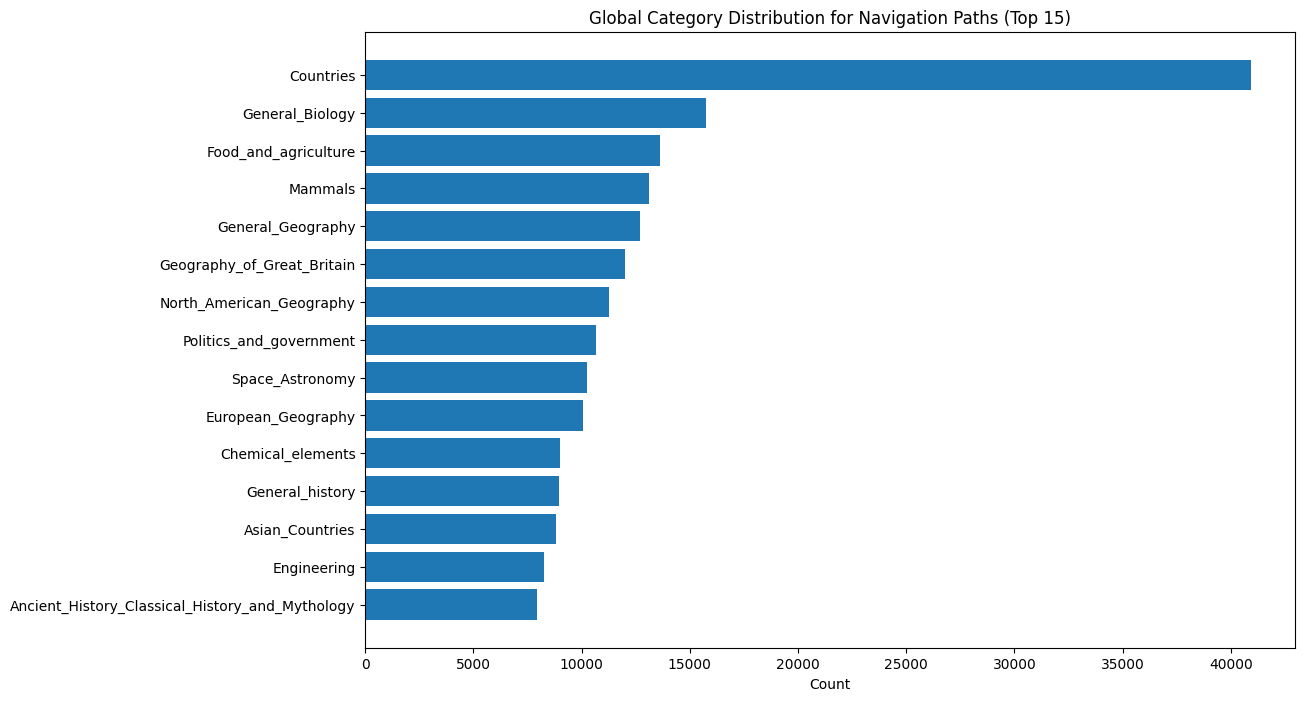

In [11]:
# Plot the 15 top categories while excluding missing categories
visualizer.visualize_category_distribution_for_paths(cat_df_clean, 'top_15_categories.png')

### Categorical Shifts

> #### What are categorical shifts?
A categorical shift happens when a navigation step moves from one article to another while changing the category. We map each article to its primary (see above =first category) category and count transitions along paths.

We use the *Preprocessor.get_category_shift_df* with *cat_df_clean* to get the top 15 most common consecutive category pairs. As you can see below within-category transitions (e.g.: Countries -> Countries) dominates this, so basically humans tend to stay in the same categories. We can also see that for example *Countries* as a category could be considered as a dominant one, since it results many self-transitions, on the other hand there are also some logical cross-category shifts, for example: *North_American_Geography (=Geography) -> Countries*.

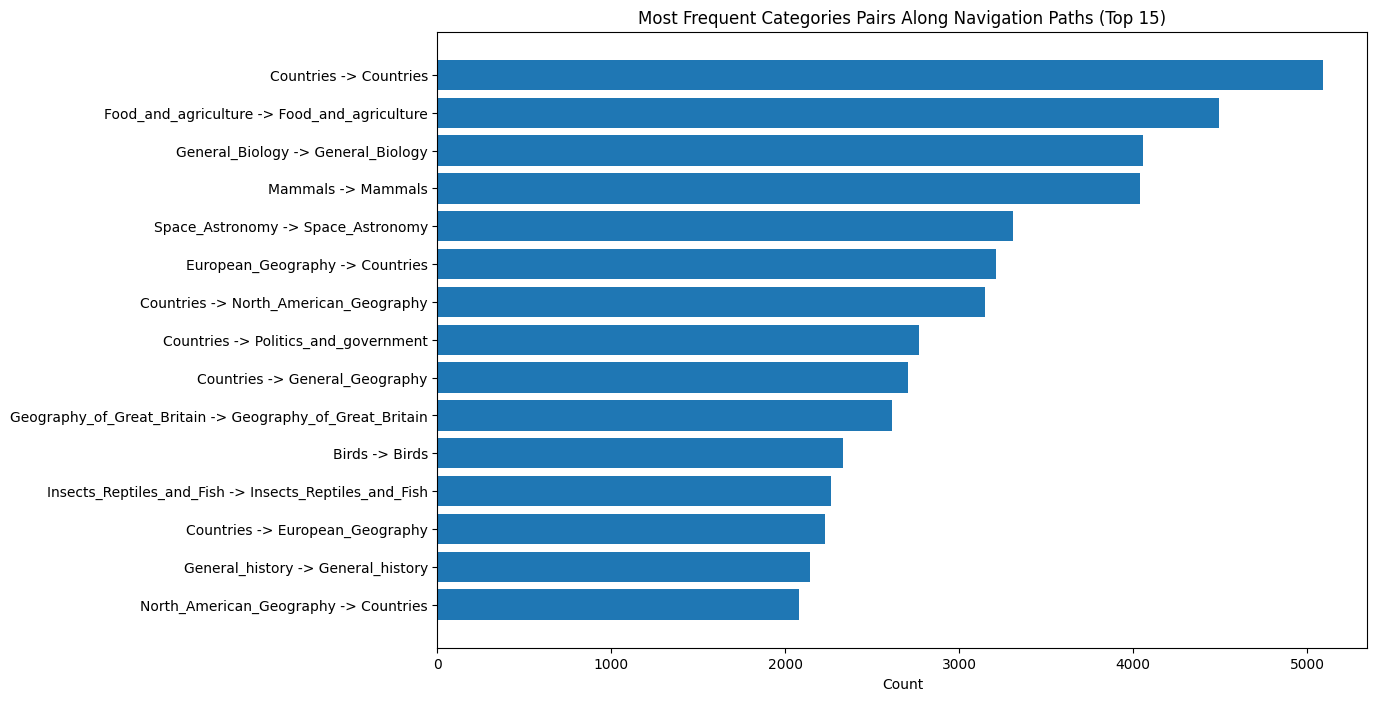

In [12]:
cat_shift_df_filter = preprocessor.get_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_categorical_shifts(cat_shift_df_filter, 'top_categorical_shifts.png')

To focus more on the cross-category shifts we exclude within-category pairs. These cross-category shifts could also be called as thematic jumps from the human players point of view. Here we also see many pairs with *Countries*, and as before *Geography -> Countries* transition or vica versa seems so abundant in the dataset, but obviously there are other transitions for example *Astronomy* -> *Planets*. Overall these changes seem logical and interconnected.

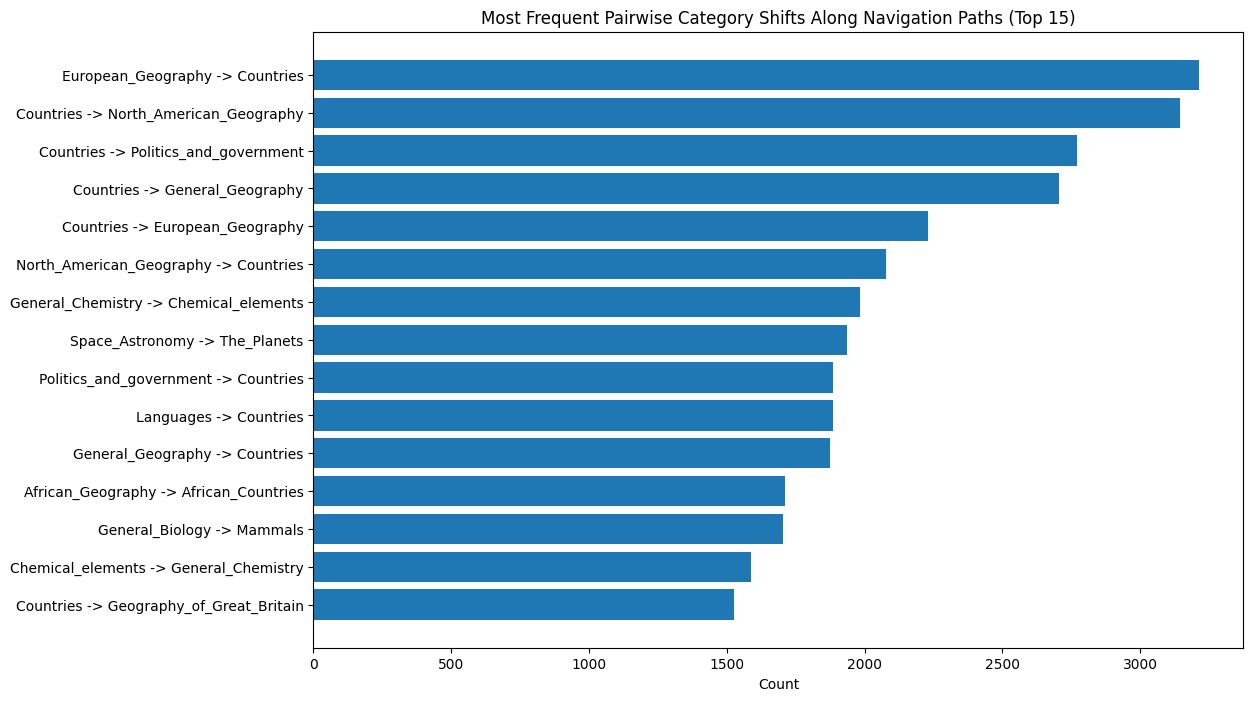

In [13]:
cat_shift_df_filter = preprocessor.get_pairwise_category_shift_df(article_cats, cat_df_clean)

# Plot the most frequent categorical shifts
visualizer.visualize_top_pairwise_categorical_shifts(cat_shift_df_filter, 'top_pairwise_categorical_shifts.png')

The Sankey visualization shows the flow of categories along finished paths for a chosen start and destination (here: *Countries -> Politics_and_government*). It highlights dominant routes, bottlenecks, and divergences in categorical space, helping to see whether navigation follows a logical flow or not. The node size reflects the number of occurences at that step, and the band thickness reflects the frequency between the consecutive categories. Note there are some nodes, which don't continue, these are the cases where the players reached their final destination.

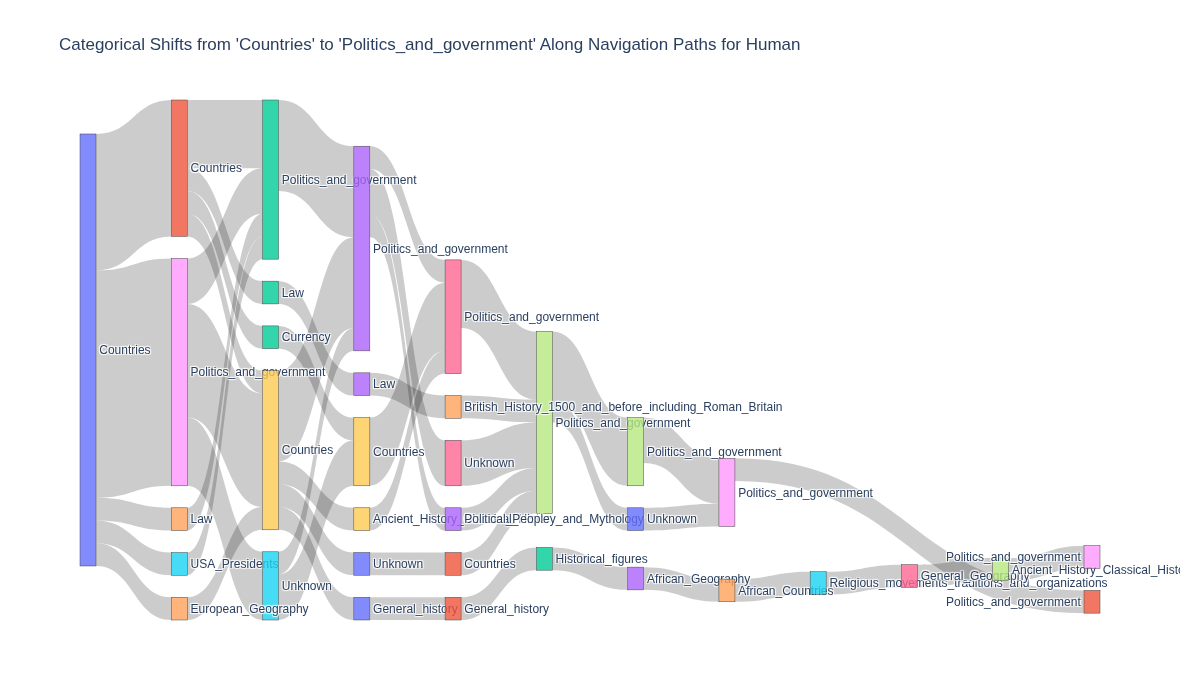

In [14]:
# Define start and end category
start_cat, end_cat = "Countries", "Politics_and_government"
cat_shift_df_pairs = preprocessor.get_category_shifts_df_pairs(article_cats_finished, start_cat, end_cat)

# Sankey diagram
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot.png'
visualizer.visualize_sankey_plot(cat_shift_df_pairs, filename, start_cat, end_cat, 'Human')

# Display the saved sankey plot
display(Image(filename=visualizer.gen_output_path(filename)))

### Finished and unfinished paths

We have access to many paths; there are 51,318 finished paths in total and 24,875 unfinished paths.

In [15]:
#number of finished vs unfinished paths
print('num of finished paths:', len(df[df['target'].isnull()]))
print('num of unfinished paths:', len(df[df['target'].notnull()]))

num of finished paths: 51318
num of unfinished paths: 24875


Some of these paths have '<' in them, indicating backtracking by human players. Since our focus of the analysis is on the semantics, we can simply skip these backtrackings. In total there are 14,196 paths which include at least 1 backtracking amongst the finished and unfinished paths.

In [16]:
# df[df['path'].astype(str).str.contains('<')].head(10)['path']
df[df['path'].astype(str).str.contains('<')].shape[0]

14196

Our strategy to handle these cases is to simply remove the page right before the '<' and the '<' character as well, which is done in the *Preprocessor.resolve_all_parsed_paths* method.

In [17]:
resolved_df = preprocessor.resolve_all_parsed_paths(df.copy())

Sanity check to make sure we removed all of the backtrackings:

In [18]:
#check if all '<' are resolved
print('num of paths with < after resolution:', resolved_df['path'].astype(str).str.contains('<').sum())

num of paths with < after resolution: 0


Some finished paths have a length of 1, indicating that the player is already at the target article, so we can simply remove those paths:


In [19]:
print('num of finished paths with length 1 before removal:', len(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)]))

# remove finished paths with length 1
filtered_finished_paths = resolved_df.drop(resolved_df.loc[(resolved_df['source'] == 'finished') & (resolved_df['num_hops'] == 1)].index)

print('num of finished paths with length 1 after removal:', len(filtered_finished_paths.loc[(filtered_finished_paths['source'] == 'finished') & (filtered_finished_paths['num_hops'] == 1)]))

num of finished paths with length 1 before removal: 11
num of finished paths with length 1 after removal: 0


### Difficulties

In our dataset (*paths_finished.tsv* and *paths_unfinished.tsv*) there is an optional user response, namely how difficult each user found the start -> destination navigation. This **rating** ranges from 1 (easy) to 5 (brutal). Looking at the distribution below, we can see those users who responded find the navigations easier, although there are some cases where they consider it as brutal.

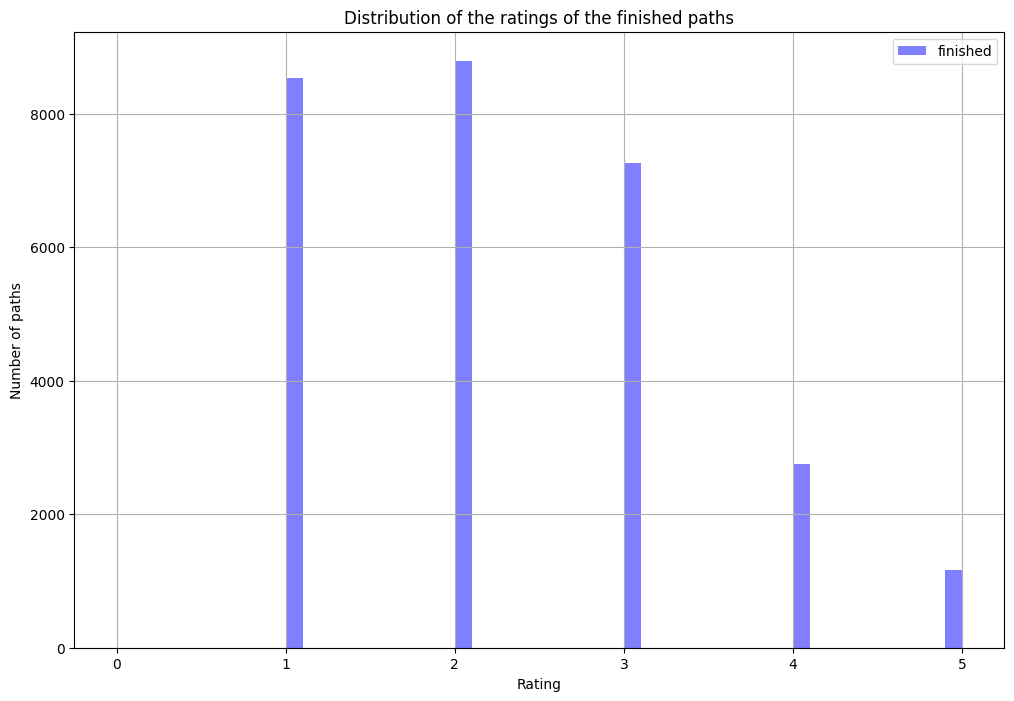

In [20]:
#get the distribution of difficulties for finished and unfinished paths
visualizer.visualize_ratings_distribution(filtered_finished_paths, 'ratings_distribution.png')

In [21]:
print(f'There are {sum(filtered_finished_paths['rating'].notna())} ratings from users out of the total {filtered_finished_paths.shape[0]} navigations.')

There are 28501 ratings from users out of the total 76182 navigations.


### Semantics

Here we explore how articles relate in meaning using embeddings generated by the *SemanticAnalyser*. The analyser builds sentence-transformer embeddings for each article title, producing a high-dimensional semantic representation where proximity reflects topical similarity.

The t-SNE plot below is basically a dimensionality reduction method to show clusters of semantically related articles. Tightly clustered regions mean topics with many closely related articles, while sparse reflect more isolated concepts. This could be interpreted as a global context for the navigation, in other words it can also be seen as a semantic space as well.

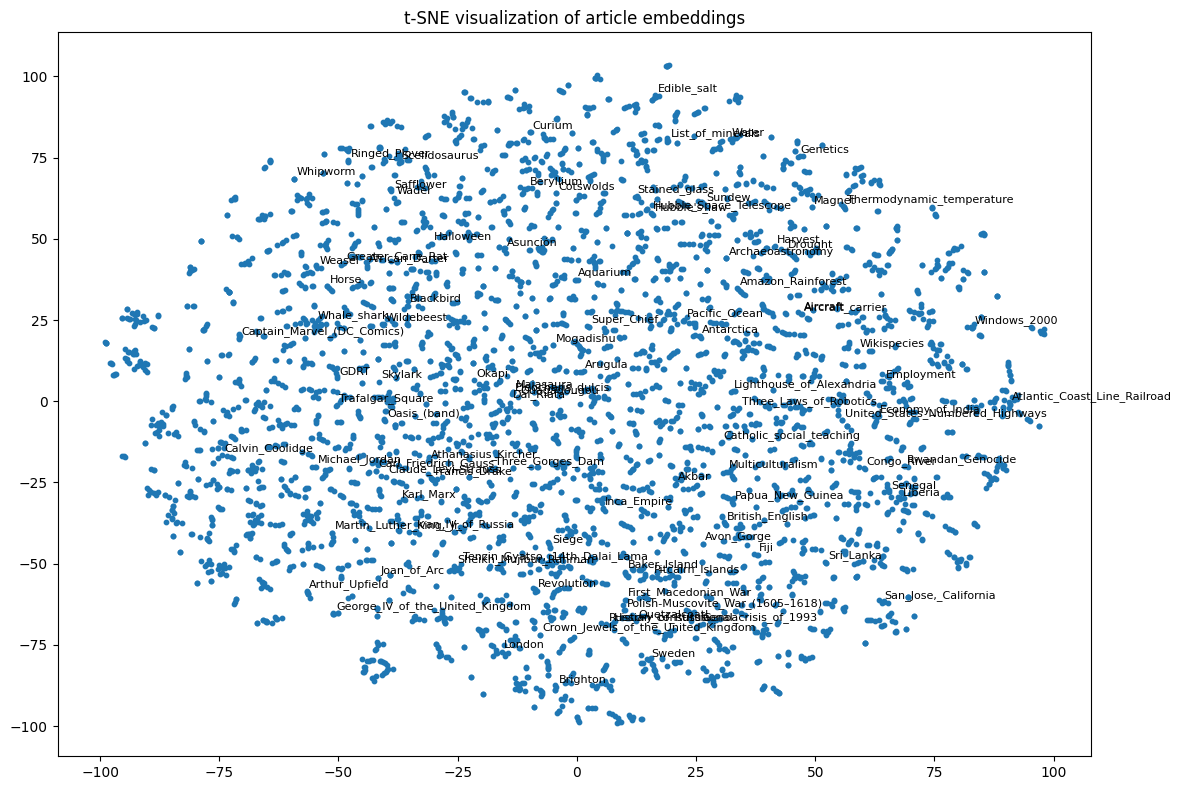

In [22]:
#semantic distribution of articles
visualizer.visualize_semantic_space(
    filename="semantic_space.png",
    metadata=articles,
    emb_path="results/article_emb/embeddings.pt"
)

### Specific path analysis (Brain -> Telephone)

#### Hop distribution

Below we can see the hop (number of pages to reach the destination) distributions for the navigation from Brain to Telephone, only considering finished paths. A single hop can be interpreted as a navigation step, for example users at the start might go from *Brain* to *Communication*, which is basically one hop.

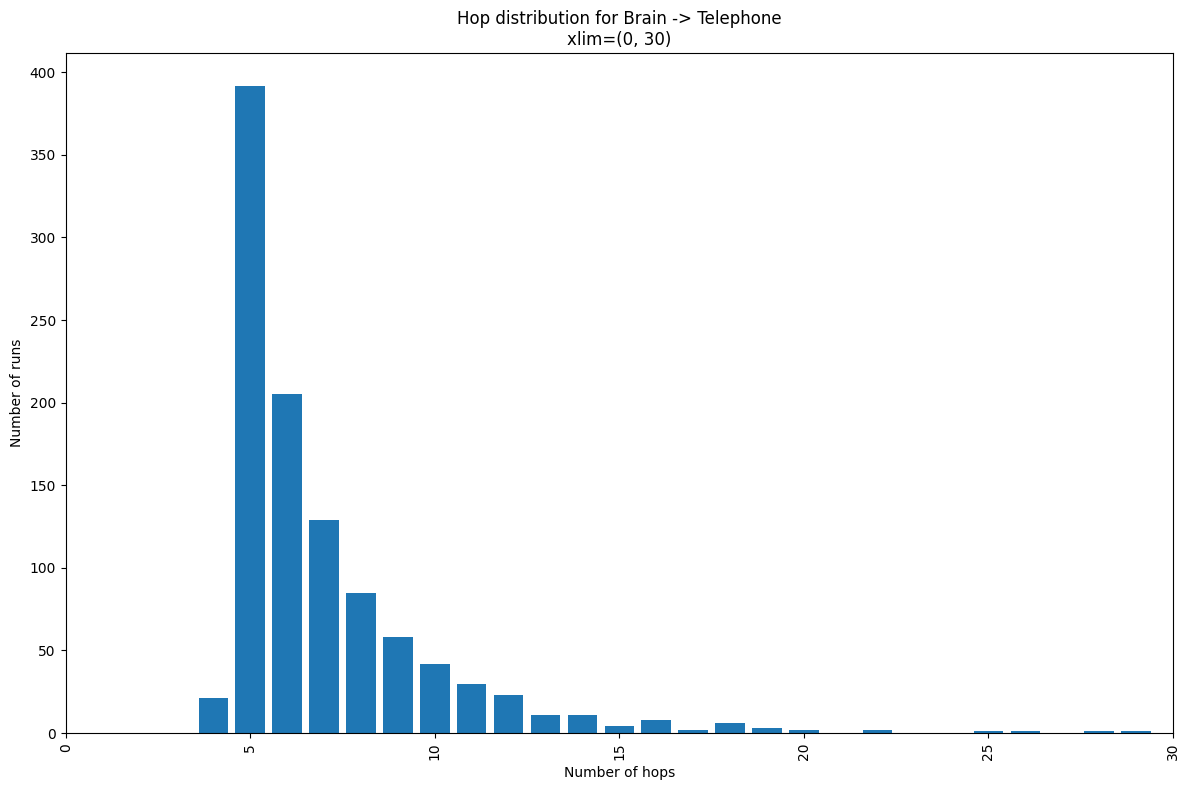

In [23]:
# hop distribtutions for Brain -> Telephone path, only considering finished paths
start, destination = 'Brain', 'Telephone'
hop_distribution = preprocessor.get_hop_distribution(df, start, destination)
visualizer.visualize_hop_distribution(
    hop_distribution,
    'brain_to_telephone_hop_distribution.png',
    (0, 30),
    start,
    destination
)

We can see for this specific navigation most of the players could finish in 5 steps (hops). The distribution itself is right skewed showing that some of the players struggled to reach the destination page.

#### Information Gain Analysis

> #### Information gain definition
Information gain quantifies how much a single hop moves us closer, to the destination (semantically). We calculate this using the previously mentioned sentence embeddings for the page titles. Our definition of information gain measures  the cosine similarity between the current article and both the start and the target and the difference in similarity to the target minus similarity to the start at each hop represents the gain.

Below in the plot we can see that early in navigation, the average gain is typically negative, meaning pages remain semantically closer to the start than to the destination. This also reflects the previously identified 'zoom-out' phase where players move away from the start to a broader context (we can observe a slight dip around 0.15 progress). Afterwards as progress increases the gain trends toward zero and then becomes positive, indicating pages become semantically closer to the destination rather than to the start. This has been identified as the 'zoom-in' or in other words the 'home in on goal' process [1].

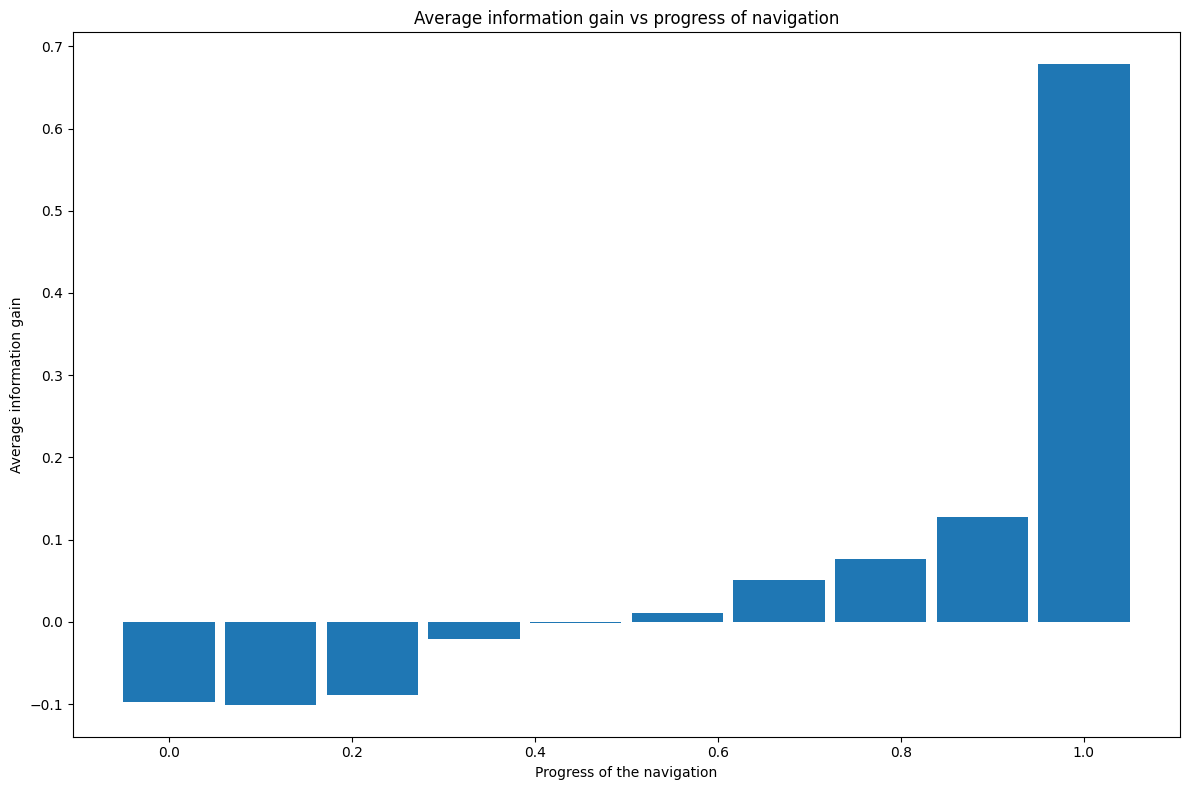

In [24]:
# generate embeddings for all the article titles, also save_dir can be overruled in config
semantic_analyser.generate_embeddings(articles)

# get all of the paths for start and destination
paths = preprocessor.get_parsed_paths(df, start, destination)

# calculate information gain by cosine similarity
avg_information_gain = semantic_analyser.get_avg_information_gain(paths)

# visualize information gain against the navigation progress
visualizer.visualize_information_gain(avg_information_gain, 'avg_information_gain_vs_progress.png')

# Generating paths with LLMs

This is the stage, wehere we use two different LLM models (gpt-oss-20b and gpt-oss-120b) to generate navigation paths between a subset of all of the start and destinations based on human players' success rate. We use different prompting strategies:

- Simple zero-shot [blind]: We ask the LLM to generate a path between the given start and destination. We don't include any checks whether the page exists in our dataset or the next page is a valid from the current one.
- Chain of thought [CoT]: Here we generate the navigation path step by step, and in each prompt we include the possible outgoing links from the current page, making the LLM hallucinate less. Besides this we also use the Auto-CoT sentence: "Let's think step by step", as well as asking the LLM a rating for the next possible steps of which we ask 3. Based on the given rating we select the top 2 pages, and based on the ratings and the length of the paths so far, we decide the best path to go with.
- Chain of thought with external information [CoT(KB)]: This is similar to the CoT prompt, the difference is that we also include some external information for each of the prompt. These information include the semantic similarity to the destination from each of the next possible pages, centrality difference between the destination and each of the next possible pages based on PageRank and the knowledge graph degrees for each of the next possible pages.
- Tree of thoughts [ToT]: Similar to CoT, but instead of a single path, we explore a branching set of navigations. At each depth level we expand 2 candidates, thus, if the destination is not found after 4 steps/hops, we will have explored 2**4 candidate navigations. We only include the outgoing links in the prompt besides the current and destination pages.

It is worth mentioning that we cap the search depth at 10, so LLM-generated paths have a maximum length of 11. In the following few blocks we show an example prompt for each of the strategies as well as an example navigation generated by *gpt-oss-120b* (the 2 numbers in the response represent the *input tokens* and the *output tokens* respectively).

In [25]:
# parsing links.tsv into pd.DataFrame
links_df = preprocessor.parse_input_file('data/wikispeedia_paths-and-graph/links.tsv')

# create link mapping from links_df
link_mappings = preprocessor.get_link_mappings(links_df)

# create high level agent instance
agent = Agent(config, link_mappings)

# blind prompt example
example_blind_prompt = agent.prompt.generate_prompt_blind(start, destination) 
log_txt = 'Example {} prompt:\n-----\n{}\n-----'
print(log_txt.format('blind', example_blind_prompt))

llm_blind_path = agent.navigate_blind(start, destination)
f'Path generated by LLM using blind approach: {llm_blind_path}'

Example blind prompt:
-----

        You are playing the Wikispeedia game.
        Start page: "Brain"
        Goal page: "Telephone"
    
        Think step-by-step and suggest a possible path of Wikipedia pages that could help reach the goal.
        - Each page in the path must be a valid Wikipedia page, and there must be a link between each consecutive page in wikipedia.
        - At each step, explain briefly why you’re choosing that link.
        - The path should start with the start page and end with the goal page.
        
        Once you’ve reached the destination, write the full path.
        Return your answer strictly following this JSON schema:
        {'properties': {'pages': {'items': {'type': 'string'}, 'title': 'Pages', 'type': 'array'}}, 'required': ['pages'], 'title': 'Path', 'type': 'object'}
        
-----
Attempt 1 starting.
Succeeded on attempt 1.


"Path generated by LLM using blind approach: (['Brain', 'Communication', 'Telephone'], 300, 246)"

In [26]:
example_cot_prompt = agent.prompt.generate_prompt(start, destination, link_mappings[start])
print(log_txt.format('CoT', example_cot_prompt))

llm_link_ware_path = agent.navigate_link_aware(start, destination)
f'Path generated by LLM using CoT approach: {llm_link_ware_path}'

Example CoT prompt:
-----

        You are playing the Wikispeedia game.
        Current page: "Brain"
        Goal page: "Telephone"
        
        Think step-by-step and suggest exactly 3 possible next Wikipedia pages that could help reach the goal.
        - Only choose from this list of valid outgoing links: ['Action_potential', 'Algorithm', "Alzheimer's_disease", 'Animal', 'Archaeology', 'Aristotle', 'Arthropod', 'Bacteria', 'Bee', 'Biology', 'Cameroon', 'Cattle', 'Cell_(biology)', 'Cerebellum', 'Charles_Darwin', 'Chordate', 'Computer_science', 'Crustacean', 'Down_syndrome', 'Edema', 'Emotion', 'Europe', 'Eye', 'Fish', 'Gorilla', 'Herodotus', "Huntington's_disease", 'Insect', 'Invertebrate', 'Kuru_(disease)', 'Lyme_disease', 'Mammal', 'Mathematics', 'Matter', 'Medicine', 'Meningitis', 'Mexico', 'Mind', 'Multiple_sclerosis', 'Papua_New_Guinea', 'Philosophy', 'Philosophy_of_mind', 'Prion', 'Protein', 'Psychology', 'Reptile', 'Schizophrenia', 'Sleep', 'Southern_United_States', 'Str

"Path generated by LLM using CoT approach: (['Brain', 'Algorithm', 'Computer', 'Electrical_engineering', 'Radio', 'Nikola_Tesla', 'Telephone'], 3368, 1689)"

In [27]:
valid_links_from_start = link_mappings[start]
external_info = agent.retrieve_graph_and_semantic_info(destination, valid_links_from_start)
example_cot_external_info_prompt = agent.prompt.generate_prompt_with_external_knowledge(start, destination, valid_links_from_start, external_info)
print(log_txt.format('CoT(KB)', example_cot_external_info_prompt))

llm_external_path = agent.navigate_with_external_info(start, destination)
f'Path generated by LLM using CoT(KB) approach: {llm_external_path}'

Example CoT(KB) prompt:
-----

        You are playing the Wikispeedia game.
        Current page: "Brain"
        Goal page: "Telephone"
        
        Think step-by-step and suggest exactly 3 possible next Wikipedia pages that could help reach the goal.
        - Only choose from this list of valid outgoing links: ['Action_potential', 'Algorithm', "Alzheimer's_disease", 'Animal', 'Archaeology', 'Aristotle', 'Arthropod', 'Bacteria', 'Bee', 'Biology', 'Cameroon', 'Cattle', 'Cell_(biology)', 'Cerebellum', 'Charles_Darwin', 'Chordate', 'Computer_science', 'Crustacean', 'Down_syndrome', 'Edema', 'Emotion', 'Europe', 'Eye', 'Fish', 'Gorilla', 'Herodotus', "Huntington's_disease", 'Insect', 'Invertebrate', 'Kuru_(disease)', 'Lyme_disease', 'Mammal', 'Mathematics', 'Matter', 'Medicine', 'Meningitis', 'Mexico', 'Mind', 'Multiple_sclerosis', 'Papua_New_Guinea', 'Philosophy', 'Philosophy_of_mind', 'Prion', 'Protein', 'Psychology', 'Reptile', 'Schizophrenia', 'Sleep', 'Southern_United_States', 

"Path generated by LLM using CoT(KB) approach: (['Brain', 'Action_potential', 'Cell_(biology)', 'Energy', 'Communication', 'Telephone'], 7202, 2062)"

In [28]:
example_tot_prompt = agent.prompt.generate_prompt(start, destination, link_mappings[start])
print(log_txt.format('ToT', example_tot_prompt))

llm_tot_path = agent.navigate_tot(start, destination)
f'Path generated by LLM using ToT approach: {llm_tot_path}'

Example ToT prompt:
-----

        You are playing the Wikispeedia game.
        Current page: "Brain"
        Goal page: "Telephone"
        
        Think step-by-step and suggest exactly 3 possible next Wikipedia pages that could help reach the goal.
        - Only choose from this list of valid outgoing links: ['Action_potential', 'Algorithm', "Alzheimer's_disease", 'Animal', 'Archaeology', 'Aristotle', 'Arthropod', 'Bacteria', 'Bee', 'Biology', 'Cameroon', 'Cattle', 'Cell_(biology)', 'Cerebellum', 'Charles_Darwin', 'Chordate', 'Computer_science', 'Crustacean', 'Down_syndrome', 'Edema', 'Emotion', 'Europe', 'Eye', 'Fish', 'Gorilla', 'Herodotus', "Huntington's_disease", 'Insect', 'Invertebrate', 'Kuru_(disease)', 'Lyme_disease', 'Mammal', 'Mathematics', 'Matter', 'Medicine', 'Meningitis', 'Mexico', 'Mind', 'Multiple_sclerosis', 'Papua_New_Guinea', 'Philosophy', 'Philosophy_of_mind', 'Prion', 'Protein', 'Psychology', 'Reptile', 'Schizophrenia', 'Sleep', 'Southern_United_States', 'Str

"Path generated by LLM using ToT approach: (['Brain', 'Computer_science', 'Information', 'Communication', 'Telephone'], 7734, 4674)"

Here we select a subset of our dataset based on the success rates of human players’ paths. Success rates between 50% and 75% are categorized as **Medium**, while those between 25% and 50% are considered as **Hard**. We selected 20 **Medium** and 20 **Hard** start–destination pairs and generated 6 replicates for each, totaling 240 paths per model. With four prompting strategies, this makes 960 (240 * 4) paths per model.

In [29]:
df_for_experiment = preprocessor.get_pairs_for_experiment(resolved_df,num_pairs=20)             
df_for_experiment.head()

,start,destination,success_count,sample_count,success_rate,difficulty,replicate_idx,id
0,Brain,Telephone,1040,2044,0.508806,Medium,0,Brain_Telephone_0
1,Theatre,Zebra,905,1777,0.509285,Medium,0,Theatre_Zebra_0
2,Asteroid,Viking,1043,1770,0.589266,Medium,0,Asteroid_Viking_0
3,Batman,Wood,148,223,0.663677,Medium,0,Batman_Wood_0
4,Beer,Sun,99,142,0.697183,Medium,0,Beer_Sun_0


This is the high-level function for the generation, which handles 429 Too Many Requests restrictions from the DigitalOcean provider, as well as includes some kind of logging in terms of token usages and also how those tokens converts to price.

In [30]:
agent.generate_llm_paths(df_for_experiment)

Found 240 already completed pairs.
So far input price: 0.66$, output price: 2.37$


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:00<00:00, 20809.38it/s]

Skipping Brain_Telephone_0, since it has already been generated.
Skipping Theatre_Zebra_0, since it has already been generated.
Skipping Asteroid_Viking_0, since it has already been generated.
Skipping Batman_Wood_0, since it has already been generated.
Skipping Beer_Sun_0, since it has already been generated.
Skipping Batman_Banana_0, since it has already been generated.
Skipping Cat_Computer_0, since it has already been generated.
Skipping Cat_Microsoft_0, since it has already been generated.
Skipping Dog_Telephone_0, since it has already been generated.
Skipping Dog_Venus_0, since it has already been generated.
Skipping Aluminium_chloride_Parrot_0, since it has already been generated.
Skipping Batman_Bible_0, since it has already been generated.
Skipping England_God_0, since it has already been generated.
Skipping Art_Mango_0, since it has already been generated.
Skipping 14th_century_Rainbow_0, since it has already been generated.
Skipping Electricity_God_0, since it has already be

# Analysis of Human players vs LLMs

Here we present the analysis code along with the results, note the detailed conclusions and interpretations can be found in the report.

## Success rate analysis

At first we load paths generated by LLMs (both from *gpt-oss-20b* and *gpt-oss-120b*).

In [31]:
llm_path_20b = pd.read_csv('results/llm_paths_merged_oss_20b.csv')
llm_path_120b = pd.read_csv('results/llm_paths_oss_120b.csv')
llm_path_120b['difficulty'] = llm_path_20b['difficulty']
llm_path_merged = pd.concat([llm_path_20b.assign(model='oss_20b'), llm_path_120b.assign(model='oss_120b')], ignore_index=True)
llm_path_merged = preprocessor.resolve_llm_path(llm_path_merged)

Since the blind prompting strategy doesn't have many valid paths compared to the successful paths, we exclude the blind prompting strategy from further analysis. (the successful criterion is that the first and last article in the generated path should be the same as the start and the destination respectively, while validity means that there is a link in our *links.tsv* for all of the consecutive articles in the generated path)

In [32]:
preprocessor.check_valid_paths(llm_path_merged, link_mappings)

Method: blind, total paths generated: 400, total successful paths: 352, total valid paths: 7
Method: CoT, total paths generated: 410, total successful paths: 279, total valid paths: 404
Method: CoT(KB), total paths generated: 394, total successful paths: 262, total valid paths: 392
Method: ToT, total paths generated: 372, total successful paths: 363, total valid paths: 367


Below are the success rates by difficulty for the two models we selected. The results are mixed: bigger is not always better. For example, the smaller 20b model performs better than the larger model with the *CoT* strategy, on the other hand *CoT(KB)* and *ToT* tend to work better with the larger model.

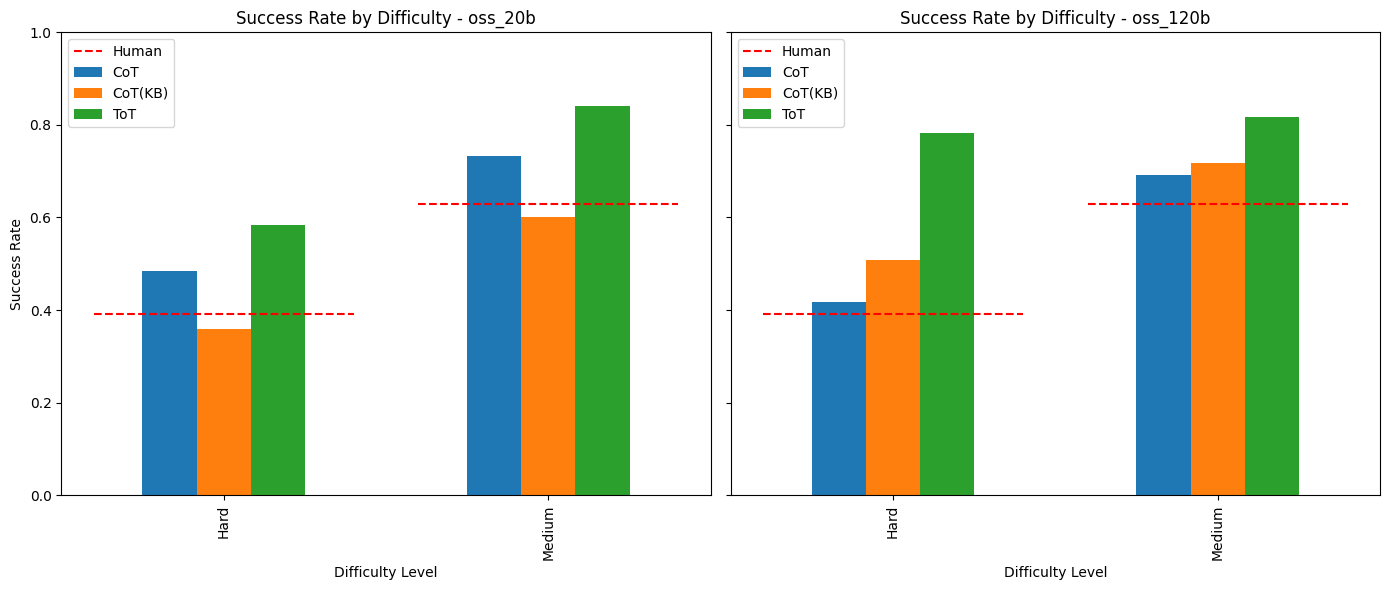

In [33]:
visualizer.visualize_success_rate(llm_path_merged, resolved_df)

Here we show the average token usage for both of the models. There isn't a consistent trend between the different models, but we can see *blind* strategy is the least token requiring method, while *ToT* requires significantly higher number of tokens. Note that tokens are basically the sum of both the input and output tokens.

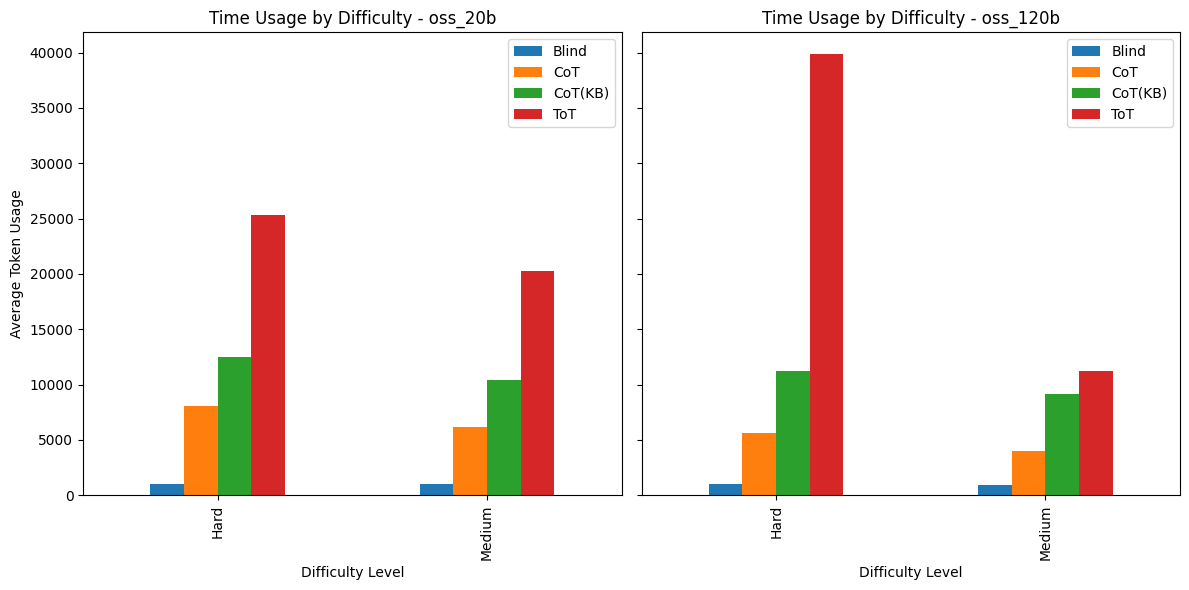

In [34]:
visualizer.visualize_time_usage(llm_path_merged)

Last but not least we show the path lengths during the LLM generation. *ToT* tends to solve the navigation in less hops compared to human players, while *CoT* and *CoT(KB)* seems to have a higher average path lengths than humans. In general this is expected since during the *ToT* method we explore a bigger space, thus the result is expected to be more efficient. 

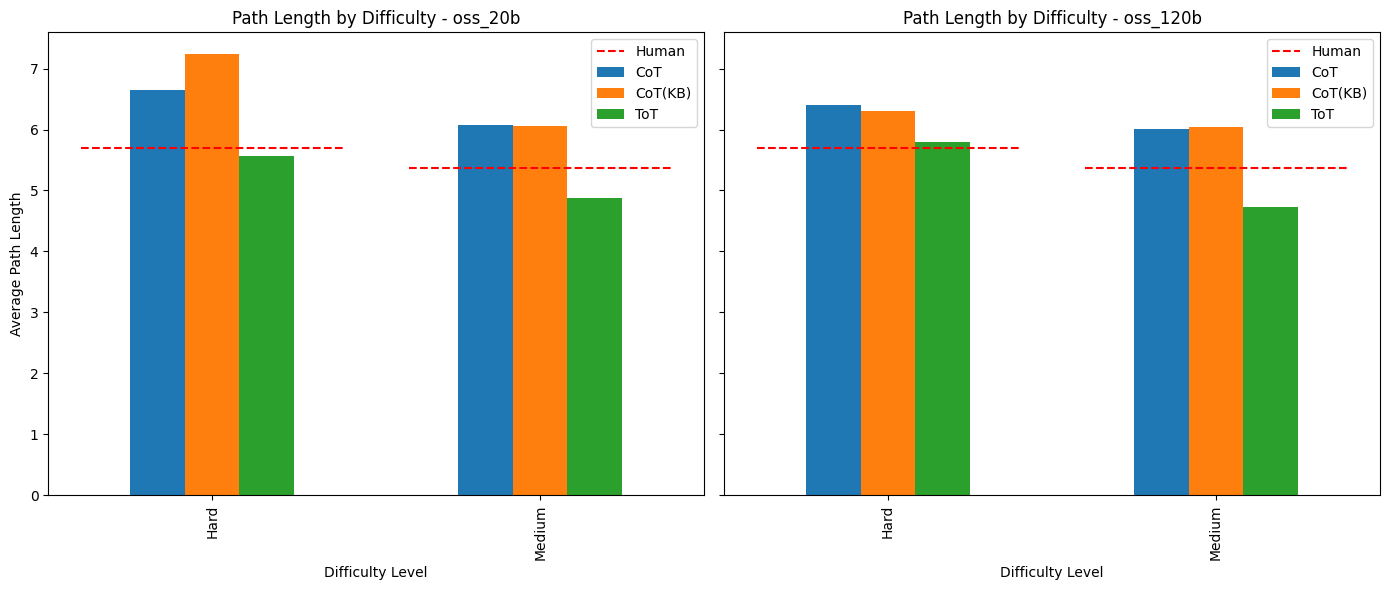

In [35]:
visualizer.visualize_path_length(llm_path_merged,resolved_df)

## Semantic analysis

Moving to the semantic analysis, at first we preprocess and clean the paths generated by the LLM.

### Data Preprocessing

#### Clean LLM generated paths

Here we filter out rows with missing or empty paths, and parses path strings into lists.

In [36]:
# Clean LLMs paths (None, NaNs, loops, hallucationed articles)
link_aware_paths = preprocessor.clean_llm_paths(llm_path_120b, "link_aware_paths")              # CoT
external_info_paths = preprocessor.clean_llm_paths(llm_path_120b, "external_info_paths")        # CoT with knowledge graph information
tot_paths = preprocessor.clean_llm_paths(llm_path_120b, "tot_paths")                            # ToT

### Semantical Similarity Comparison

#### Align Human Data (Finished paths for Wikispeedia) with the LLM paths generated

Ensure we only use the start/destination paths where an LLM example exists and we also downsample to ensure same no. of path support for pairs. Besides this we filter out human paths with maximum length of 11 since the LLM generation has a depth cap of 10, so our analysis is comparable.

In [37]:
# Align Wikispeedia human players with the LLM generated pahts (i.e., there is a lot more human data than LLM data)
human_path_samples, _ = preprocessor.get_human_llm_match_samples(df, [link_aware_paths, external_info_paths, tot_paths], max_len=11, seed=42)

#### Load embeddings and metadata

The embeddings are the previously mentioned sentence-transformer embeddings and its metadata.

In [38]:
embeddings = torch.load("results/article_emb/embeddings.pt", weights_only=True).numpy()
metadata = pd.read_csv("results/article_emb/metadata.csv")
article_to_idx = {row['article']: i for i, row in metadata.iterrows()}

#### Get the *mean similarity*, *progress axis*, *stepwise similarity* and *mean information gains*. Here are the interpreatation of each of them:

- *stepwise_similarity*: For each path, we compute cosine similarity between consecutive page embeddings and then store these for each group (human and other prompting strategies).
- *mean_similarity*: For each group, we resample stepwise similarity sequences onto a shared normalized progress_axis, and then take the mean across paths to get an average of the similarity.
- *mean_information_gains*: For each path, at each step, compute previously defined information gain.
- *progress_axis*: The common normalized 0–1 progress used to align paths of varying length for fair averaging across groups.

In [39]:
sem_sim_dict = {
    "Humans": human_path_samples,
    "CoT": link_aware_paths["path_list"].tolist(),
    "CoT(KB)": external_info_paths["path_list"].tolist(),
    "ToT": tot_paths["path_list"].tolist()
}

mean_similarity, progress_axis, stepwise_similarity, mean_information_gains = preprocessor.compute_stepwise_mean_similarity(
    sem_sim_dict,
    article_to_idx,
    embeddings
)

#### Plot the path length distributions

Here you can see the raw path length distribution. As we discussed previously we have a cap of 10 regarding the depth of the LLM paths, thus we also applied filtering for the human paths mentioned above. We can see humans tend to have higher number of steps on average to finish the navigation, and ToT seems to have a tighter distributions compared to the other prompting strategies.

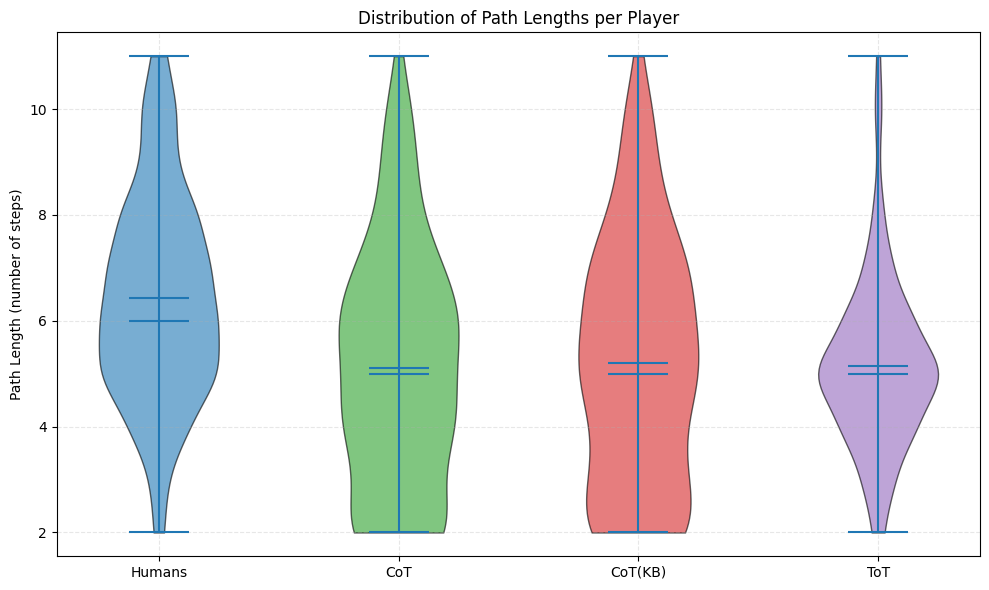

In [40]:
visualizer.plot_path_length_distribution(groups=sem_sim_dict)

#### Plot temporal normalized progress plot showing the step-wise mean similarity

We visualize the *mean_similarity* against the *progress_axis*. Our conclusions and interpreatation are in the report.

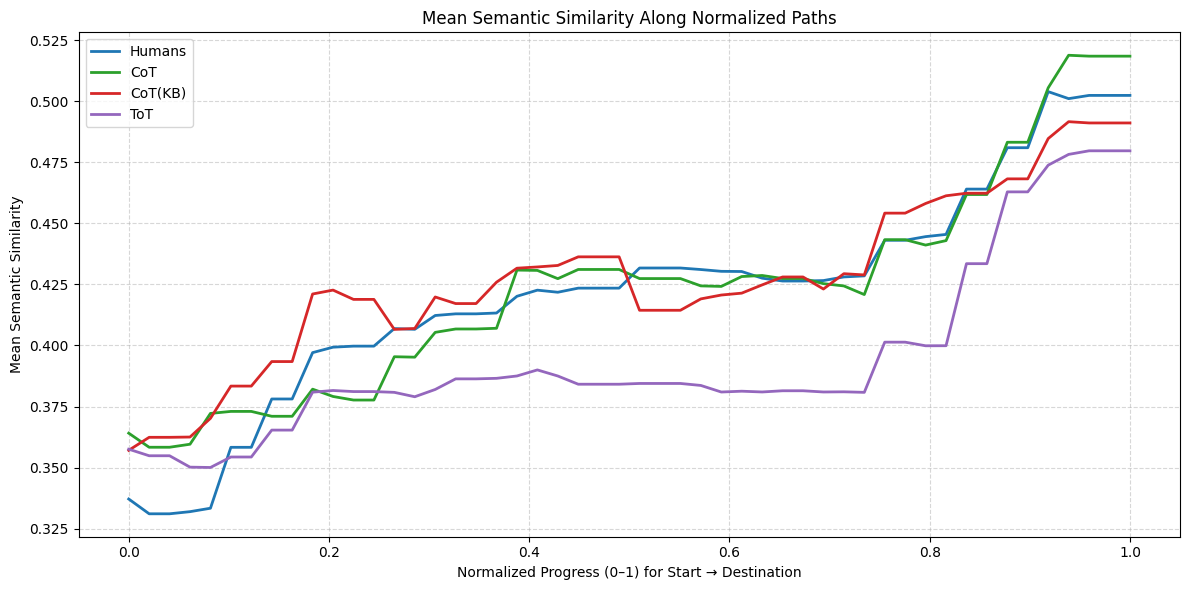

In [41]:
# Chart showing the step-weise mean similarity over normalized progress [0,1]
visualizer.visualize_stepwise_mean_similarity(mean_similarity, progress_axis)

We visualize the *mean_information_gains* against the *progress_axis*. Our conclusions and interpretations are in the report.

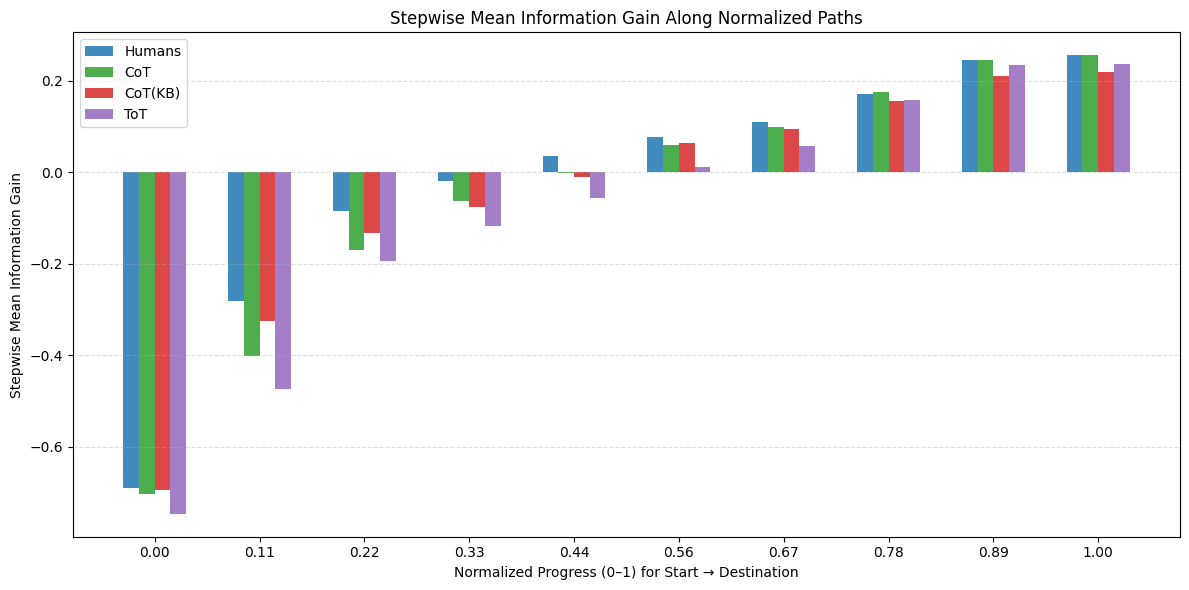

In [42]:
visualizer.visualize_stepwise_mean_information_gain(mean_information_gains, progress_axis)

#### Step-wise mean similarity distribution

Computes, for each group, a single flattened list of cosine similarities between consecutive pages across all its paths, clipping each similarity to the [0, 1] interval.

Based on the below visualization, humans and CoT(KB) tend to make steadier, more semantically aligned steps; CoT is similar but a bit more variable, ToT explores more broadly, producing more lower-similarity hops and a slightly lower mean.

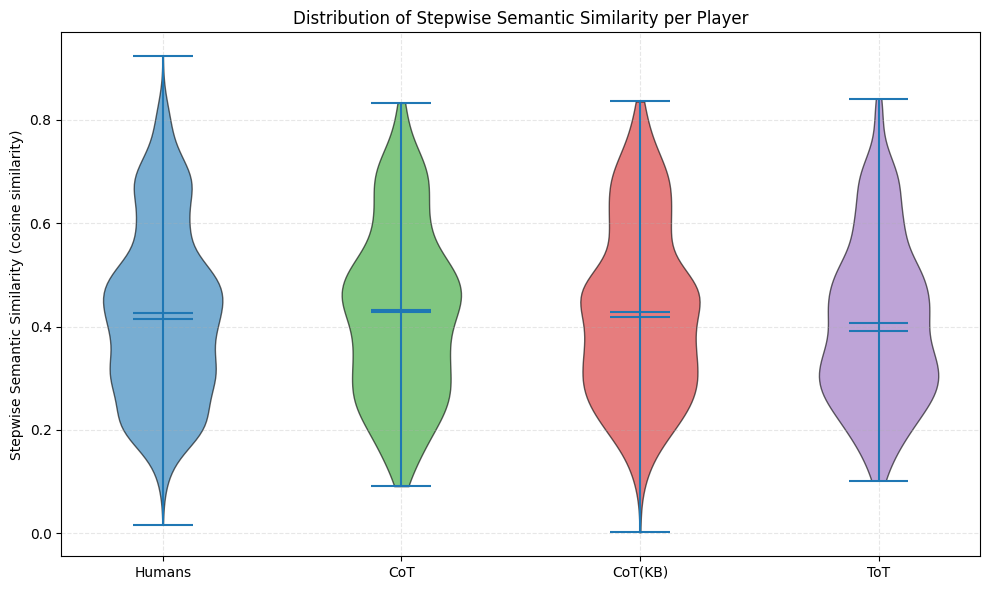

In [43]:
stepwise_similarity_flat = preprocessor.compute_flat_stepwise_similarity(
    groups=sem_sim_dict,
    article_to_idx=article_to_idx,
    embeddings=embeddings
)

visualizer.plot_stepwise_similarity_violin(stepwise_similarity_flat)

An example CoT navigation in the semantic space (by the 20b model):

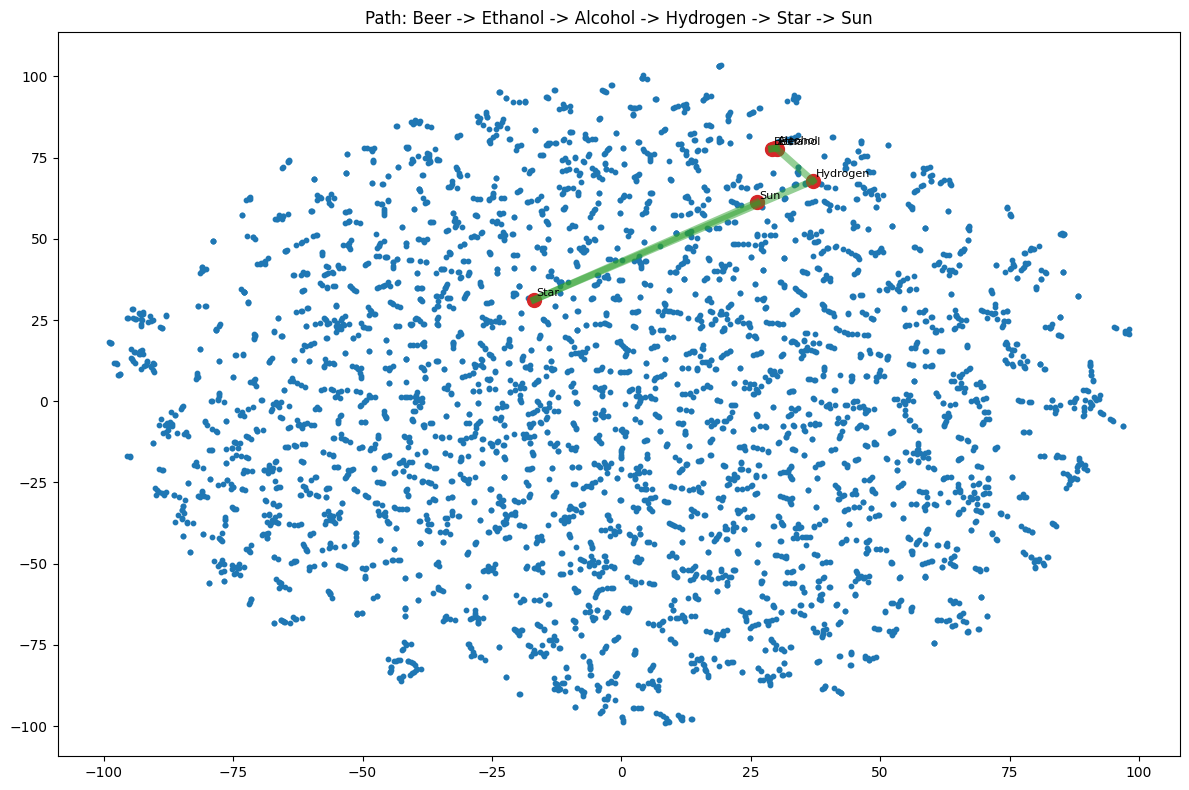

In [44]:
path_example= llm_path_merged.iloc[4]['link_aware_paths']
visualizer.visualize_specific_semantic_space(
    metadata=articles,
    emb_path="results/article_emb/embeddings.pt",
    article_titles=path_example
)  

The same navigation but by a human player:

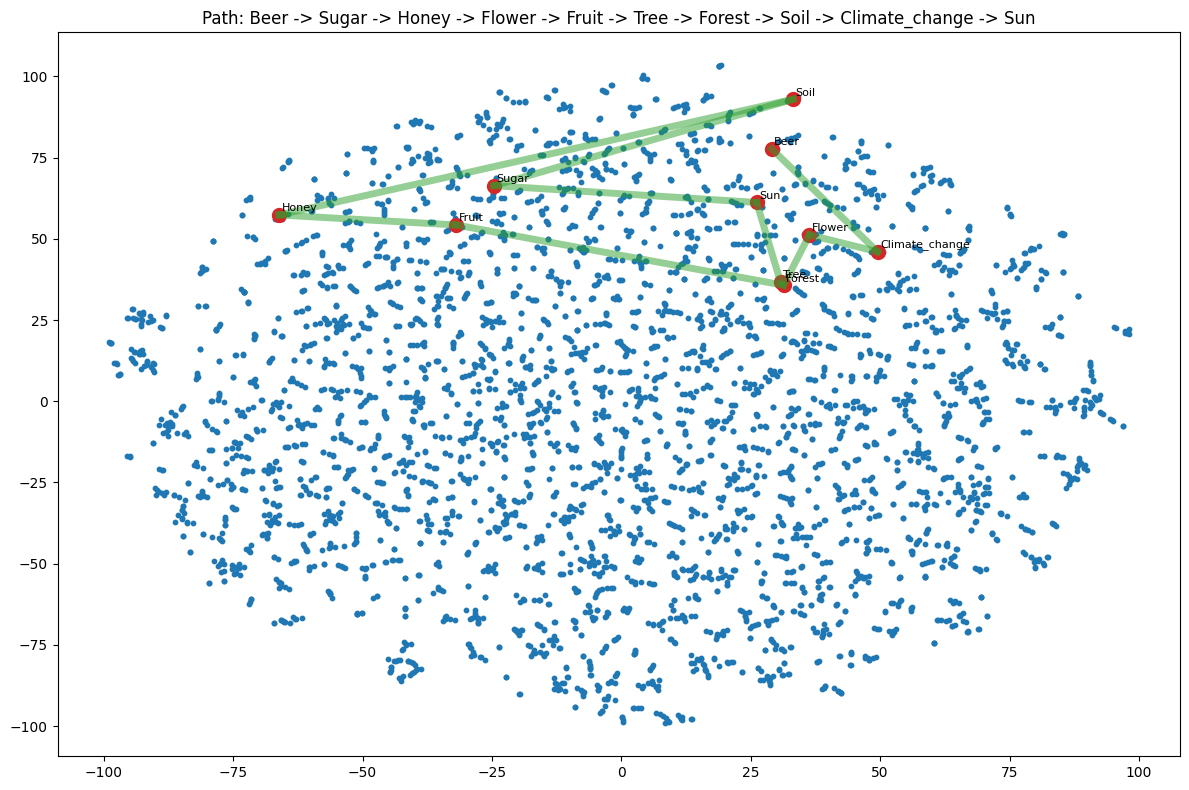

In [45]:
start = llm_path_merged.iloc[4]['start']
destination = llm_path_merged.iloc[4]['destination']
human_paths = resolved_df[(resolved_df['start'] == start) & (resolved_df['destination'] == destination) & (resolved_df['end'].notnull())]['path'].tolist()
if human_paths:
    human_path = human_paths[0]  # take the first successful human path
    visualizer.visualize_specific_semantic_space(
        metadata=articles,
        emb_path="results/article_emb/embeddings.pt",
        article_titles=human_path
    )

For this specific example we can see the human player explored a bigger semantic space during the navigation, but this is only an example, so we can't really conclude anything based on this, thus the other aggregate comparisons.

### Categorical Shifts

At first we extract the categories to dictionary, so later we can map them to the different paths.

In [46]:
# Get caterories
categories = preprocessor.parse_input_file(config.input_file_categories)

# Define method to extract the categories for the  article -> category mappings
article_to_cat = (
    categories.assign(cat_short=categories["category"].str.split(".").str[-1])
    .groupby("article")["cat_short"]
    .apply(list)
    .to_dict()
)

#### Map LLMs Player Article Navigation Paths to Categories

In [47]:
# Map all LLM paths to categories
# Link aware paths: CoT
link_aware_article_cats = [
    [article_to_cat.get(article, ["Unknown"])[0] for article in path]
    for path in link_aware_paths['path_list']
]

# External info paths:  CoT with knowledge graph information
external_info_article_cats = [
    [article_to_cat.get(article, ["Unknown"])[0] for article in path]
    for path in external_info_paths['path_list']
]

# ToT paths: ToT with a maximum depth of 14 and for each layer
tot_article_cats = [
    [article_to_cat.get(article, ["Unknown"])[0] for article in path]
    for path in tot_paths['path_list']
]

#### Map Human Player Article Navigation Paths to Categories

In [48]:
# Only finished paths (perhaps a better idea for the salluviate plot?)
df_finished = df[df["source"] == "finished"].copy()

# Map all articles in the navigation paths to its first category (mapping missing articles to 'unknown' as there is no category list available)
article_cats = [article_to_cat.get(p, ["Unknown"])[0] for path in df["path"] for p in path.split(";")]
# For finished path (not flattened): used for the  alluviate plot
article_cats_finished = [[article_to_cat.get(p, ["Unknown"])[0] for p in path.split(";")]for path in df_finished["path"]]

### Stepwise Mean Categorical Shifts Comparison

Compute the number of categorical shifts per navigation path and the corresponding proportion. Here categorical shift is the same as explained in the *Explanatory analysis* section.

In [49]:
# Link aware paths: CoT
link_aware_paths_shift, link_aware_steps_shift = preprocessor.get_shifts_per_path(link_aware_article_cats)

# External info paths:  CoT with knowledge graph information
external_info_paths_shift, external_info_steps_shift = preprocessor.get_shifts_per_path(external_info_article_cats)

# ToT paths: ToT with a maximum depth of 14 and for each layer
tot_paths_shift, tot_steps_shift = preprocessor.get_shifts_per_path(tot_article_cats)

Compute the categorical shifts per navigatin path and step for Humans

In [50]:
# Humans: Categorical shifts per navigatin path
shifts_path_humans, shifts_step_humans = preprocessor.get_shifts_per_path(article_cats_finished)

Compare the average categorial shifts along the entire navigation paths

In [51]:
# Compute average categorical shifts per navigation path for Humans
average_shift_humans = preprocessor.get_average_categorical_shifts_path(article_cats_finished)
print(f"Average categorical shift along entire navigation paths (Humans): {average_shift_humans:.3f}")

# Compute average categorical shifts per navigation path for LLMs:
# Link aware paths: CoT
average_shift_link_aware = preprocessor.get_average_categorical_shifts_path(link_aware_article_cats )
print(f"Average categorical shift along entire navigation paths (link_aware_paths): {average_shift_link_aware:.3f}")

# External info paths:  CoT with knowledge graph information
average_shift_external_info = preprocessor.get_average_categorical_shifts_path(external_info_article_cats )
print(f"Average categorical shift along entire navigation paths (external_info_paths): {average_shift_external_info:.3f}")

# ToT paths: ToT with a maximum depth of 14 and for each layer
average_shift_tot = preprocessor.get_average_categorical_shifts_path(tot_article_cats )
print(f"Average categorical shift along entire navigation paths (tot_paths): {average_shift_tot:.3f}")

Average categorical shift along entire navigation paths (Humans): 4.577
Average categorical shift along entire navigation paths (link_aware_paths): 3.074
Average categorical shift along entire navigation paths (external_info_paths): 3.183
Average categorical shift along entire navigation paths (tot_paths): 3.206


In [52]:
# Compute proportion of consecutive article pairs (i.e., per navigatio step)  involving a categorical shift for Humans
average_shift_steps_humans = preprocessor.get_average_categorical_shifts_step(article_cats_finished)
print(f"Proportion of consecutive article pairs involving a categorical shift (Humans): {average_shift_steps_humans:.3f}")

# Compute proportion of consecutive article pairs (i.e., per navigatio step) involving a categorical shift for LLMs
print("=====================================================================================")
print(f"Proportion of consecutive article pairs involving a categorical shift For LLMs:")

# Link aware paths: CoT
average_shift_step_link_aware = preprocessor.get_average_categorical_shifts_step(link_aware_article_cats)
print(f"CoT {average_shift_step_link_aware:.3f}")

# External info paths:  CoT with knowledge graph information
average_shift_step_external_info = preprocessor.get_average_categorical_shifts_step(external_info_article_cats)
print(f"CoT (KB): {average_shift_step_external_info:.3f}")

# ToT paths: ToT with a maximum depth of 14 and for each layer
average_shift_step_tot = preprocessor.get_average_categorical_shifts_step(tot_article_cats)
print(f"ToT: {average_shift_step_tot:.3f}")

Proportion of consecutive article pairs involving a categorical shift (Humans): 0.795
Proportion of consecutive article pairs involving a categorical shift For LLMs:
CoT 0.750
CoT (KB): 0.759
ToT: 0.773


#### Compare step-wise mean categorical shits along the entire navigation paths (normalized as progress [0,1])

The *Preprocessor.compute_stepwise_shift_vectors* basically does a one-hot encoding, where **1** means there is a categorical shift in a hop (between a -> b navigation step) and **0** means we stayed in the same category during the hop.

In [53]:
# Compute stepwise shift vectors for each player type
shifts_step_humans       = preprocessor.compute_stepwise_shift_vectors(article_cats_finished)
link_aware_steps_shift   = preprocessor.compute_stepwise_shift_vectors(link_aware_article_cats)
external_info_steps_shift= preprocessor.compute_stepwise_shift_vectors(external_info_article_cats)
tot_steps_shift          = preprocessor.compute_stepwise_shift_vectors(tot_article_cats)

cat_shift_dict = {
    "Humans": shifts_step_humans,
    "CoT": link_aware_steps_shift,
    "CoT(KB)": external_info_steps_shift,
    "ToT": tot_steps_shift
}

Here we visualize the stepwise mean categorical shifts against the normalized progress. The conclusions and the interpretations can be found in the report.

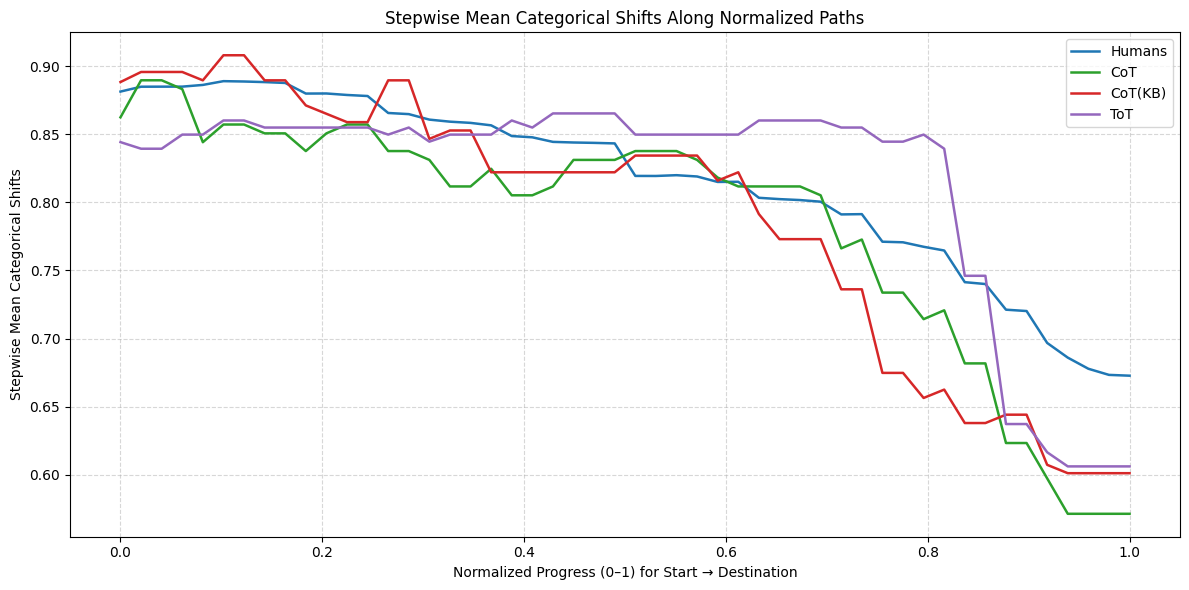

In [54]:
# Compute stepwise mean categorical shifts
mean_shifts_normal = preprocessor.compute_stepwise_mean_shifts(cat_shift_dict)

# Plot Step-wise mean categorical shifts (Paths normalized [0,1])
visualizer.visualize_categorical_shifts_mean_stepwise(mean_shifts_normal)

#### Examining Categorical Shifts for a Specific Path

Our focus is on the Humans vs. ToT, since ToT is the best performing prompting method based on the **Success rate analysis** above. Here we try to get the top navigations which align the most with the human navigations. Based on this simple matching logic we can see *Cartoons* -> *Food_and_agriculture* is the highest representative start and destination categories amongst our LLM generated paths, that's why we focus on this specific categorical path.

In [55]:
# Start and destinations pairs for human players
hum_pairs = set((x[0], x[-1]) for x in article_cats_finished)

# Start and destinations pairs for ToT
tot_pairs = [(x[0], x[-1]) for x in tot_article_cats]

# Pair matches between them
hum_tot_matches = [p for p in tot_pairs if p in hum_pairs]

# Top 5 matching pairs
hum_tot_matches_top = (
    pd.Series(hum_tot_matches)
      .value_counts()
      .head(5)
)

# Print top matches
hum_tot_matches_top

(Cartoons, Food_and_agriculture)        14
(Mammals, Engineering)                   6
(Chemical_compounds, Birds)              6
(Architecture, Food_and_agriculture)     6
(Asian_Countries, Space_Astronomy)       6
Name: count, dtype: int64

In [56]:
# Count how many times the match occur for each: Because need the same sample size and by the match count, we know that one of them only contain 14 samples
# Count in humans
hum_match_count = sum(
    1 for path in article_cats_finished
    if (path[0], path[-1]) == hum_tot_matches_top.index[0]
)

# Count for ToT 
tot_match_count = sum(
    1 for path in tot_article_cats
    if (path[0], path[-1]) == hum_tot_matches_top.index[0]
)

# Print no. of support for each player 
print(f"Top pair {hum_tot_matches_top.index[0]} occurs {hum_match_count} times in human paths.")
print(f"Top pair {hum_tot_matches_top.index[0]} occurs {tot_match_count} times in LLM paths.")

Top pair ('Cartoons', 'Food_and_agriculture') occurs 121 times in human paths.
Top pair ('Cartoons', 'Food_and_agriculture') occurs 14 times in LLM paths.


The discrepancy in support effectively mean we have to take 14 random samples from human players to ensure a fair comparison. Furhtermore, we limit the max length of the human players to 11 as above these for ToT resulted in hallucinations



In [57]:
# Filter human paths for the pair and constraint to a max length of 11
human_top_paths = [
    path for path in article_cats_finished
    if (path[0], path[-1]) == hum_tot_matches_top.index[0] and len(path) <= 11
]

# Select 14 random samples
human_sampled = random.sample(human_top_paths, 14)

# Print to ensure we have correct no. of samples
print(f"Human samples: {len(human_sampled)}")

Human samples: 14


#### Compare Humans against ToT using a Sankey Diagram

We calculate the previously mentioend categorical shifts for these 14 samples for both the Humans and ToT, and then visualize them in a Sankey diagram. The conclusions and the interpretations can be found in the report.

In [58]:
# Define start and end category for humans
cat_shift_hum_pairs = preprocessor.get_category_shifts_df_pairs(human_sampled, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1])

# Define start and end category for ToT
cat_shift_tot_pairs = preprocessor.get_category_shifts_df_pairs(tot_article_cats, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1])

#### Human Sankey Diagram

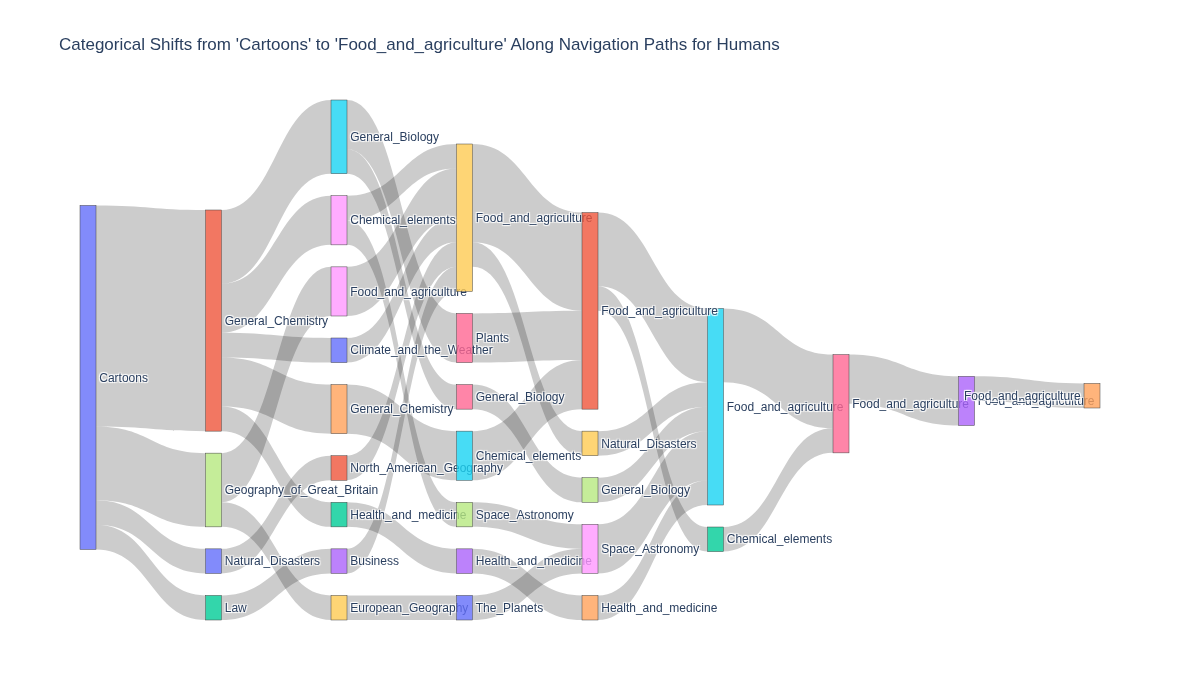

In [59]:
# Sankey diagram
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot_humans.png'
visualizer.visualize_sankey_plot(cat_shift_hum_pairs, filename, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1], "Humans")

# Display the saved sankey plot
from IPython.display import Image, display
display(Image(filename=visualizer.gen_output_path(filename)))

#### ToT Sankey Diagram

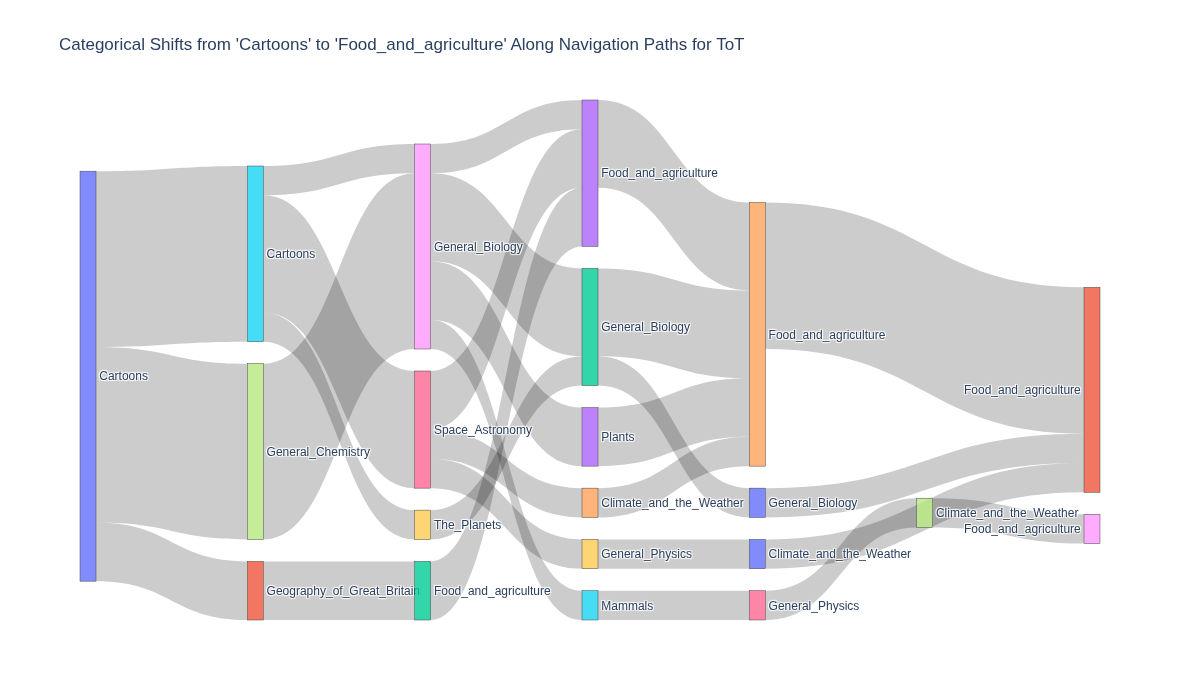

In [60]:
# Sankey diagram for ToT
# Reference: https://plotly.com/python/sankey-diagram/
filename = 'cat_shift_plot_tot.png'
visualizer.visualize_sankey_plot(cat_shift_tot_pairs, filename, hum_tot_matches_top.index[0][0], hum_tot_matches_top.index[0][1], "ToT")

# Display the saved sankey plot
from IPython.display import Image, display
display(Image(filename=visualizer.gen_output_path(filename)))

# References

[1] - West, Robert & Pineau, Joelle & Precup, Doina. (2009). Wikispeedia: An Online Game for Inferring Semantic Distances between Concepts.. IJCAI International Joint Conference on Artificial Intelligence. 1598-1603. 